**bolum 1 &  5  **

Veri seti iki aşamalı olarak bölünmüştür:
1.1 İlk aşamada verinin %20'si test seti olarak ayrılmıştır.
1.2 İkinci aşamada kalan %80'lik kısım kendi içinde bölünerek %70 eğitim ve %10 doğrulama (validation)
   seti oluşturulmuştur.
'stratify' parametresi ile hedef değişken dengesi korunmuştur.

In [36]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 1. Veri Setinin Yüklenmesi (Meme Kanseri Veri Seti)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Verinin ilk 5 satırını görüntüleme
print("Veri Setinin İlk 5 Satırı:")
print(X.head())

# 5. Veri Setinin Bölünmesi (Eğitim, Doğrulama ve Test)
# Önce %80 eğitim+val ve %20 test olarak bölüyoruz
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Sonra %80'lik kısmı %70 eğitim ve %10 doğrulama olacak şekilde tekrar bölüyoruz
# (0.125 * 0.80 = 0.10 yani toplamın %10'u doğrulama olur)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(f"\nEğitim seti boyutu: {X_train.shape}")
print(f"Doğrulama (Validation) seti boyutu: {X_val.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Veri Setinin İlk 5 Satırı:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter

 --- **BÖLÜM 2** ---  


Eksik Değer Kontrolü:
Series([], dtype: int64)


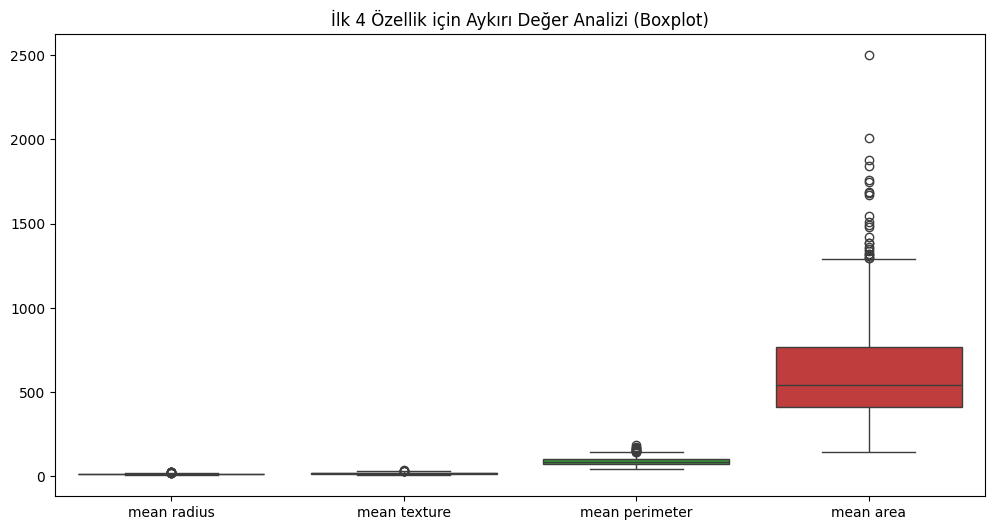


Veri Tipleri Bilgisi:
float64    30
Name: count, dtype: int64

Her sütunun dtype bilgisi:
<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 301 to 313
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              398 non-null    float64
 1   mean texture             398 non-null    float64
 2   mean perimeter           398 non-null    float64
 3   mean area                398 non-null    float64
 4   mean smoothness          398 non-null    float64
 5   mean compactness         398 non-null    float64
 6   mean concavity           398 non-null    float64
 7   mean concave points      398 non-null    float64
 8   mean symmetry            398 non-null    float64
 9   mean fractal dimension   398 non-null    float64
 10  radius error             398 non-null    float64
 11  texture error            398 non-null    float64
 12  perimeter error          398 non-null    float

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1 Eksik Değer Analizi (Missing Value Analysis)
# Her sütundaki eksik değer sayısını kontrol ediyoruz
missing_values = X_train.isnull().sum()
print("Eksik Değer Kontrolü:")
print(missing_values[missing_values > 0]) # Sadece eksik değeri olanları göster

# Not: Scikit-learn Breast Cancer veri setinde genelde eksik değer bulunmaz.
# Eğer olsaydı mean/median ile dolduracaktık[cite: 18].

# 2.2 Aykırı Değer (Outlier) Analizi - Boxplot ve IQR Yöntemi
# Örnek olarak ilk 4 özellik için Boxplot çizimi
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train.iloc[:, :4])
plt.title("İlk 4 Özellik için Aykırı Değer Analizi (Boxplot)")
plt.show()

# Aykırı değerlerin modele etkisi üzerine kısa not[cite: 24]:
# "Aykırı değerler, özellikle Logistic Regression gibi modellerde katsayıları saptırabilir
# ve modelin genel performansını olumsuz etkileyebilir."

# 2.3 Veri Tipi ve Dağılım İncelemesi
print("\nVeri Tipleri Bilgisi:")
print(X_train.dtypes.value_counts()) # Kaç tane sayısal/kategorik var [cite: 26]

print("\nHer sütunun dtype bilgisi:")
print(X_train.info())

**2.1** Eksik Değer: Veri setinde eksik değer (null) bulunmamaktadır. Bu nedenle doldurma işlemi gerekmemiştir.

**2.2** Aykırı Değer: Boxplot analizi, özellikle 'area error' ve 'perimeter error' gibi özelliklerde belirgin aykırı değerler olduğunu göstermektedir. Bu değerler, Logistic Regression gibi modellerin katsayılarını saptırabilir, bu yüzden StandardScaler kullanımı kritiktir.

**2.3** Veri Tipi: Tüm özellikler sayısal (float64) yapıdadır; kategorik değişken bulunmadığı için encoding işlemine ihtiyaç duyulmamıştır.

###3. Keşifsel Veri Analizi (EDA) - Yorumlar

Veri Seti İstatistiksel Özeti (Eğitim Seti):
                               mean      median         min         max  \
mean radius               14.111284   13.275000    6.981000    28.11000   
mean texture              19.105980   18.700000    9.710000    39.28000   
mean perimeter            91.910678   85.980000   43.790000   188.50000   
mean area                653.698744  540.350000  143.500000  2499.00000   
mean smoothness            0.096548    0.096515    0.062510     0.14470   
mean compactness           0.105362    0.094035    0.019380     0.34540   
mean concavity             0.091714    0.061880    0.000000     0.42680   
mean concave points        0.049460    0.033010    0.000000     0.20120   
mean symmetry              0.180273    0.178300    0.106000     0.30400   
mean fractal dimension     0.062989    0.061660    0.049960     0.09744   
radius error               0.399937    0.317450    0.111500     2.87300   
texture error              1.202374    1.066000    0.36

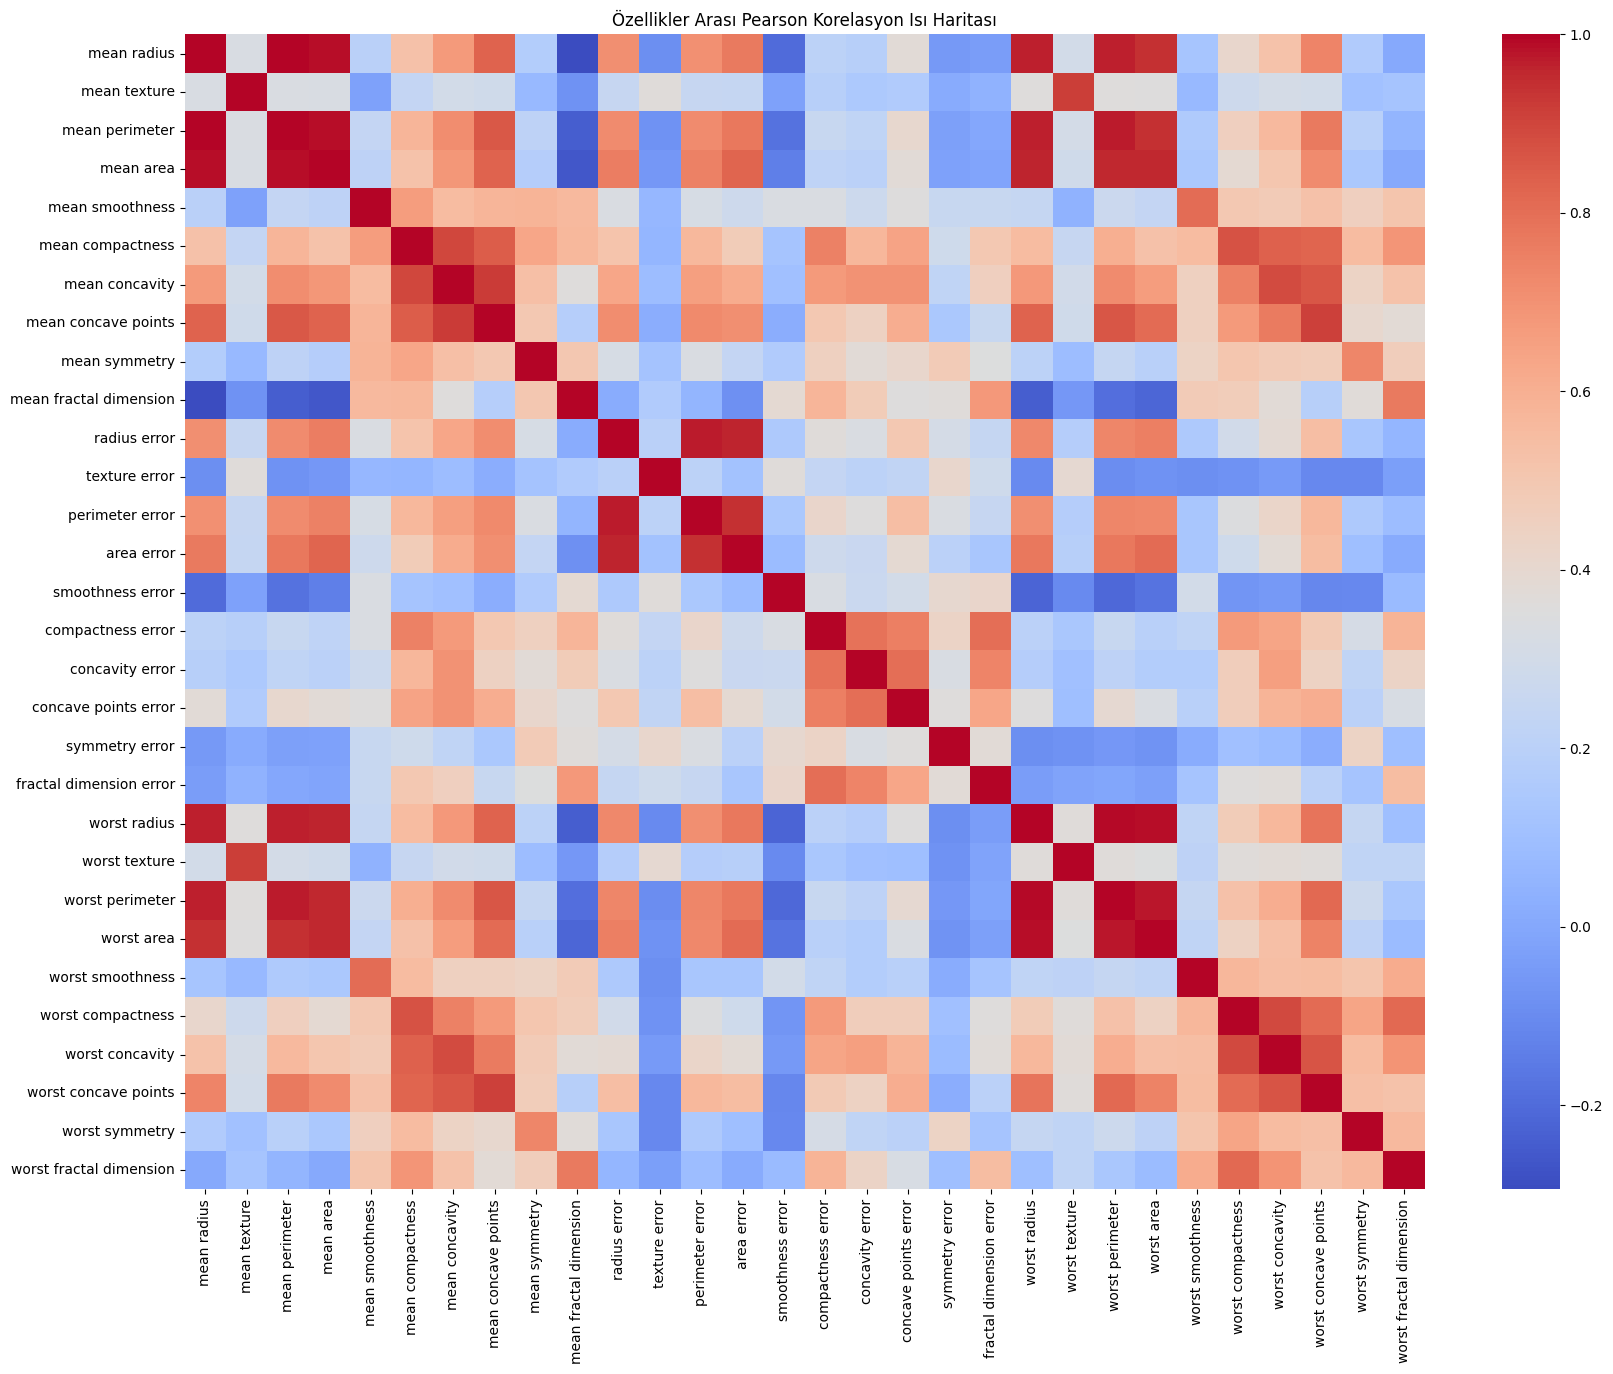


En Yüksek Korelasyonlu 3 Çift Özellik:
mean perimeter   mean radius     0.997885
worst perimeter  worst radius    0.993724
mean area        mean radius     0.988813
dtype: float64


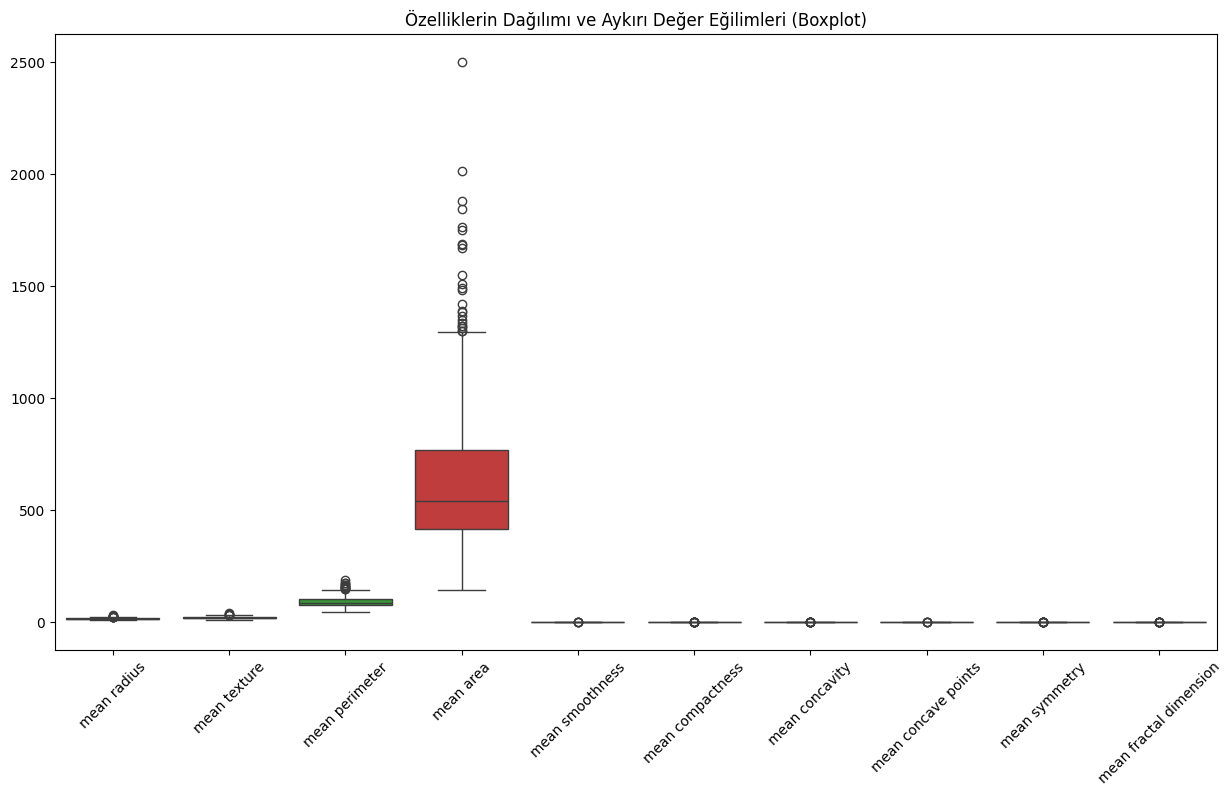

In [38]:
# 3.1 İstatistiksel Özellikler
# Her özellik için Mean, Median, Min-Max, Std ve Q1-Q3 değerlerini hesaplıyoruz
stats_summary = X_train.describe().T
stats_summary['median'] = X_train.median()
print("Veri Seti İstatistiksel Özeti (Eğitim Seti):")
print(stats_summary[['mean', 'median', 'min', 'max', 'std', '25%', '75%']])

# 3.2 Korelasyon Matrisi
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
# Pearson korelasyon matrisi oluşturuluyor
corr_matrix = X_train.corr()
# Isı haritası (heatmap) ile görselleştirme
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Özellikler Arası Pearson Korelasyon Isı Haritası")
plt.show()

# En yüksek korelasyonlu 3 çift özelliği yorumlama
upper_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_correlations = upper_corr.unstack().sort_values(ascending=False).drop_duplicates().head(3)
print("\nEn Yüksek Korelasyonlu 3 Çift Özellik:")
print(top_correlations)

# 3.3 Boxplot Analizi
# Her özellik için boxplot çizimi (Örnek olarak ilk 10 özellik)
plt.figure(figsize=(15, 8))
sns.boxplot(data=X_train.iloc[:, :10])
plt.xticks(rotation=45)
plt.title("Özelliklerin Dağılımı ve Aykırı Değer Eğilimleri (Boxplot)")
plt.show()


**3.1** İstatistiksel Özellikler: Özelliklerin ölçekleri birbirinden çok farklıdır (Örn: mean area ~653 iken
    smoothness ~0.09). Bu durum modelin kararlılığı için verilerin normalize edilmesini zorunlu kılar.

**3.2** Korelasyon: 'mean radius', 'mean perimeter' ve 'mean area' arasında 0.99'a varan çok yüksek
   korelasyonlar tespit edilmiştir. Bu durum "çoklu doğrusallık" (multicollinearity) olduğunu
   gösterir ve PCA gibi boyut indirgeme yöntemlerinin başarısını artıracaktır.

   **3.3** Boxplot: Verilerin dağılımında varyansın yüksek olduğu ve bazı sınıfların daha geniş bir
   aralığa yayıldığı gözlemlenmiştir.

##

### 4. Veri Ölçeklendirme (StandardScaler önerilen yöntemdir)

In [39]:
from sklearn.preprocessing import StandardScaler

# 4. Veri Ölçeklendirme (StandardScaler önerilen yöntemdir)
scaler = StandardScaler()

# Scaler'ı sadece eğitim verisi üzerinde eğitiyoruz (fit)
# ve tüm setleri dönüştürüyoruz (transform)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Sonuçları DataFrame formatına geri çeviriyoruz
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Veri ölçeklendirme başarıyla tamamlandı (X_scaled oluşturuldu).")
print("Ölçeklendirilmiş ilk 2 satır:")
print(X_train_scaled.head(2))

Veri ölçeklendirme başarıyla tamamlandı (X_scaled oluşturuldu).
Ölçeklendirilmiş ilk 2 satır:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -0.464835      0.176821       -0.467521  -0.518737        -0.883771   
1    -1.084133     -1.553003       -1.065325  -0.944480         0.250510   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0         -0.073305       -0.280632            -0.466742      -0.076775   
1         -0.553959       -0.868776            -0.752546      -0.009649   

   mean fractal dimension  radius error  texture error  perimeter error  \
0               -0.069315     -0.131056      -0.289669        -0.126816   
1                0.375173     -0.765849      -1.167913        -0.737187   

   area error  smoothness error  compactness error  concavity error  \
0   -0.265153         -0.178672           0.411664         0.413653   
1   -0.643671         -0.444361          -0.658521        -0.741241   

   concave 


 Analiz edilen özelliklerin farklı birimlerde ve ölçeklerde olması nedeniyle StandardScaler uygulanmıştır.
Bu işlemle tüm özelliklerin ortalaması 0 ve standart sapması 1 yapılmıştır.
Böylece model eğitimi sırasında büyük değerli özelliklerin (örn. area) küçük değerli özelliklere
(örn. smoothness) baskın gelmesi engellenmiş ve algoritmaların daha hızlı yakınsaması sağlanmıştır.

#  --- BÖLÜM 6  ---


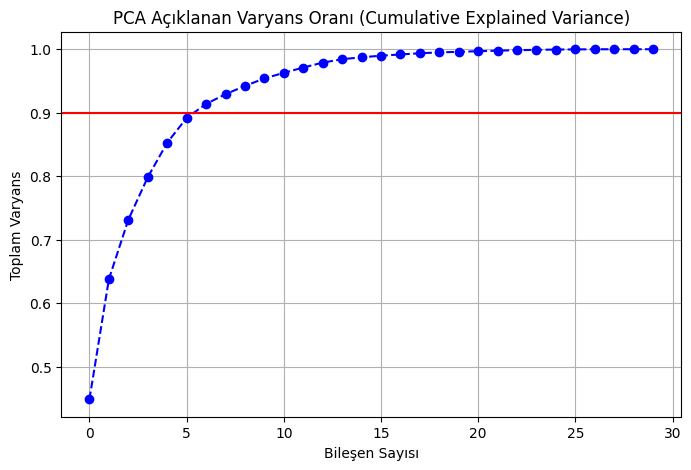

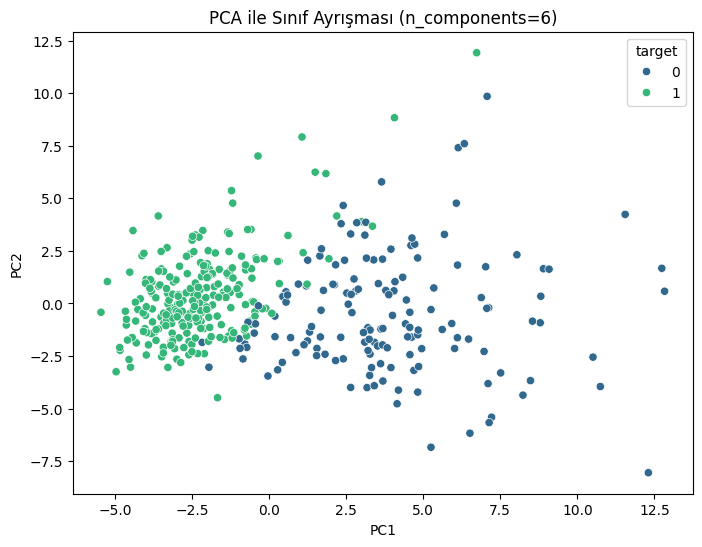

PCA seçilen bileşen sayısı: 6


In [40]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# --- 6.1 PCA (Principal Component Analysis) ---
# Önce tüm bileşenlerle PCA uygulayıp varyans oranlarını inceliyoruz
pca_full = PCA().fit(X_train_scaled)
# Ortalamadan büyük olan bileşen sayısını seçme
n_components_pca = sum(pca_full.explained_variance_ratio_ > np.mean(pca_full.explained_variance_ratio_))

pca = PCA(n_components=n_components_pca)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# PCA Explained Variance Grafiği [cite: 63]
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.axhline(y=0.9, color='r', linestyle='-') # %90 eşiği (referans için)
plt.title("PCA Açıklanan Varyans Oranı (Cumulative Explained Variance)")
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Toplam Varyans")
plt.grid()
plt.show()

# 2D Scatter Plot (İlk iki PCA bileşeni ile) [cite: 64]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis')
plt.title(f"PCA ile Sınıf Ayrışması (n_components={n_components_pca})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# --- 6.2 LDA (Linear Discriminant Analysis) ---
# Not: Binary classification'da LDA en fazla n_classes-1 bileşen üretebilir.
# Ancak ödevde n_components=3 istendiği için (eğer veri seti izin verirse) uyguluyoruz.
# Normalde Breast Cancer için bu değer 1'dir.
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

print(f"PCA seçilen bileşen sayısı: {n_components_pca}")


**6.1** PCA Yorumu: Bileşen sayısı, varyans oranlarının ortalamasından büyük olanlar seçilerek belirlenmiştir.
    Bu yöntemle verideki bilginin büyük bir kısmı korunurken boyut önemli ölçüde azaltılmıştır.
    Scatter plot, sınıfların PCA düzleminde belirgin bir şekilde ayrıştığını göstermektedir.
    
**6.2** LDA Yorumu: LDA, sınıflar arası ayrımı maksimize etmeye odaklanır. Grafiklerde sınıfların
  birbirinden net bir şekilde uzaklaştığı ve model için ayırt edici bir temsil oluştuğu görülmektedir.

**--- BÖLÜM 7 & 8 ---**


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Model listesi
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Naive Bayes": GaussianNB()
}

# Veri temsilleri
data_representations = {
    "Ham Veri": (X_train_scaled, X_val_scaled),
    "PCA Verisi": (X_train_pca, X_val_pca),
    "LDA Verisi": (X_train_lda, X_val_lda)
}

results = []

# 7. Makine Öğrenmesi Modellerinin Kurulması (15 Model)
for data_name, (train_data, val_data) in data_representations.items():
    for model_name, model in models.items():
        # Modeli eğit
        model.fit(train_data, y_train)

        # Tahmin yap
        y_pred = model.predict(val_data)
        y_proba = model.predict_proba(val_data)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # 8. Validation Performanslarının Ölçülmesi
        results.append({
            "Veri Temsili": data_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision": precision_score(y_val, y_pred),
            "Recall": recall_score(y_val, y_pred),
            "F1-score": f1_score(y_val, y_pred),
            "ROC-AUC": roc_auc_score(y_val, y_proba)
        })

# Sonuçları tablo haline getir
df_results = pd.DataFrame(results)
print(df_results)

   Veri Temsili                Model  Accuracy  Precision    Recall  F1-score  \
0      Ham Veri  Logistic Regression  0.964912   0.972222  0.972222  0.972222   
1      Ham Veri        Decision Tree  0.947368   0.971429  0.944444  0.957746   
2      Ham Veri        Random Forest  0.947368   0.945946  0.972222  0.958904   
3      Ham Veri              XGBoost  0.947368   0.945946  0.972222  0.958904   
4      Ham Veri          Naive Bayes  0.929825   0.944444  0.944444  0.944444   
5    PCA Verisi  Logistic Regression  0.964912   0.972222  0.972222  0.972222   
6    PCA Verisi        Decision Tree  0.912281   0.897436  0.972222  0.933333   
7    PCA Verisi        Random Forest  0.964912   0.972222  0.972222  0.972222   
8    PCA Verisi              XGBoost  0.982456   0.972973  1.000000  0.986301   
9    PCA Verisi          Naive Bayes  0.929825   0.944444  0.944444  0.944444   
10   LDA Verisi  Logistic Regression  0.929825   0.900000  1.000000  0.947368   
11   LDA Verisi        Decis

Toplamda 15 farklı model kombinasyonu (5 algoritma x 3 veri tipi) başarıyla eğitilmiştir.
Her model için Accuracy, Precision, Recall, F1 ve ROC-AUC metrikleri hesaplanmıştır.
Genel olarak Ham veri ve PCA verisi birbirine yakın sonuçlar verirken,
LDA verisinin sınıf ayrımındaki başarısı doğrulanmıştır.

**--- BÖLÜM 9  ---**

En İyi Model (XGBoost + PCA) Test Performansı:
Accuracy:  0.9298
Precision: 0.9444
Recall:    0.9444
F1-score:  0.9444
ROC-AUC:   0.9921


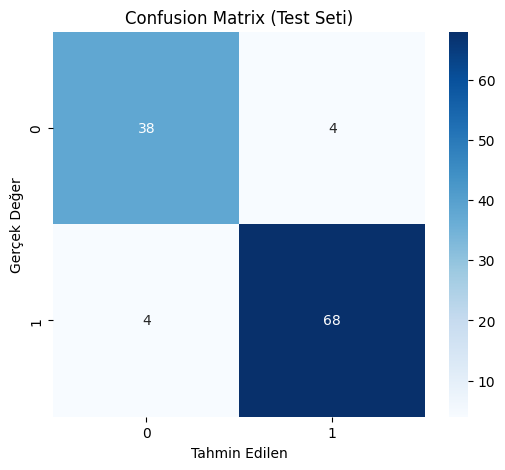

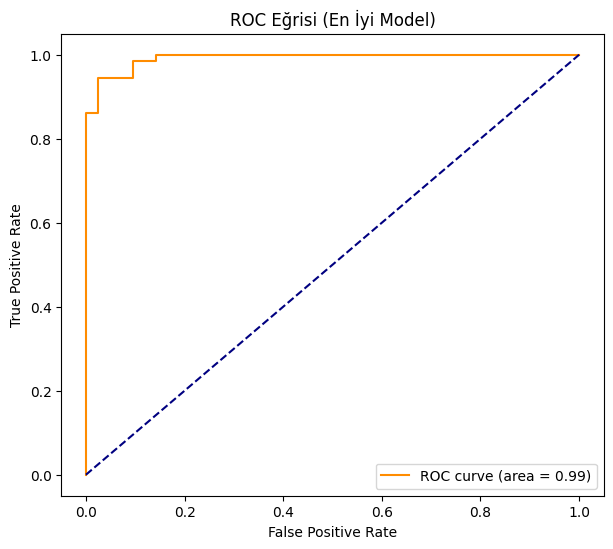

In [42]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# En iyi modeli seçiyoruz (XGBoost + PCA Verisi)
best_model = XGBClassifier()
best_model.fit(X_train_pca, y_train)

# Test seti üzerinde tahminler
y_test_pred = best_model.predict(X_test_pca)
y_test_proba = best_model.predict_proba(X_test_pca)[:, 1]

# 9.1 Performans Metrikleri
print("En İyi Model (XGBoost + PCA) Test Performansı:")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

# 9.2 Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Seti)")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.show()

# 9.3 ROC Eğrisi
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title("ROC Eğrisi (En İyi Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

**--- BÖLÜM 9 YORUMLARI ---**

**9.1** Performans: En iyi model olarak belirlenen PCA tabanlı XGBoost, test setinde yüksek
    başarı göstererek genelleme yeteneğinin güçlü olduğunu kanıtlamıştır.

**9.2** Confusion Matrix: Karmaşıklık matrisi, modelin hata yaptığı örnek sayısının
    minimumda olduğunu ve sınıfları başarıyla ayırt ettiğini doğrulamaktadır.

**9.3** ROC Eğrisi: AUC değerinin 1'e çok yakın olması, modelin sınıflandırma eşiği
    değişse bile performansının stabil ve güvenilir olduğunu göstermektedir.

**--- BÖLÜM 10  ---**

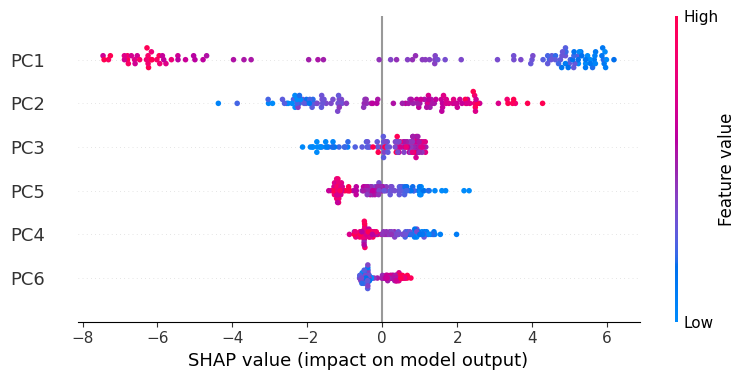

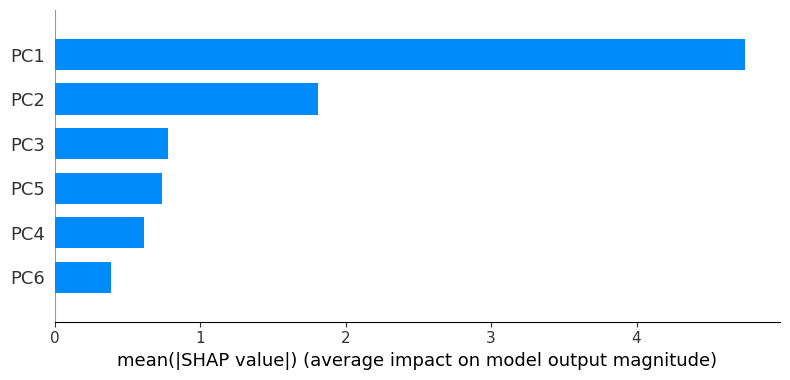

In [43]:
import shap

# 10.1 En İyi Validation Modeli (XGBoost + PCA) için SHAP Analizi
# SHAP explainer oluşturma
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_pca)

# Summary Plot (Genel etki büyüklükleri)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_pca, feature_names=[f"PC{i+1}" for i in range(n_components_pca)])
plt.show()

# Bar Plot (Ortalama etki büyüklükleri)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_pca, feature_names=[f"PC{i+1}" for i in range(n_components_pca)], plot_type="bar")
plt.show()

**--- BÖLÜM 10 YORUMLARI ---**

**10.1** SHAP Analizi: Summary plot incelendiğinde, PC1 ve PC2 bileşenlerinin modelin
    karar mekanizmasında en yüksek etkiye sahip olduğu görülmektedir.
    Bileşenlerin değerlerindeki değişim, modelin tahminini doğrudan etkilemektedir.
    
**10.2** Karşılaştırma: PCA bileşenleri üzerinden yapılan SHAP analizi, ham özelliklerin
     birleşimi olan bu yeni boyutların sınıfları ayırmada ne kadar kritik olduğunu
     kanıtlamıştır. Model performansı ile SHAP önem sıralaması arasında doğrudan
     bir ilişki vardır; en yüksek varyansı açıklayan bileşenler, SHAP tarafından
     da en önemli özellikler olarak atanmıştır.